# 01 — The saturated benchmark

**Second of five.** Findings **F1** and **F2**.

The question: *in a published architecture that concatenates a 128-dimensional
graph embedding with a 768-dimensional BERT embedding, what does each half
actually contribute?*

The answer has two parts, and the second is the surprising one.

1. **F1 — the branches are substitutes, not complements.** Either half alone
   reaches about 0.973–0.978 accuracy; together they reach 0.978. Five raw
   metadata numbers with a small non-linear head reach 0.9775 *using no text at
   all*.
2. **F2 — the 128-dimensional "network embedding" contains exactly the
   information in 10 numbers**, and this is provable from the layer's closed
   form rather than merely observed. You will compute it here.

Everything is Cresci-2015, 5-fold stratified CV, **majority baseline 0.6321**,
fold σ ≈ **0.0063**.

### Running this notebook

Pinned to the kernel `ext-research` — the `.venv` beside the project. Register it
once, from the repository root:

```bash
02-ext-research/.venv/bin/python -m ipykernel install \
    --user --name ext-research --display-name "Python (02-ext-research)"
```

**It runs on a clean checkout with no data and no results.** `.gitignore` excludes
`results/` at every level, and the corpora are gigabytes behind author
applications, so nothing here reads `data/` or `results/`. Measured numbers are
**hard-coded as verified constants** in the cell below, each carrying the file it
came from and the line of
`01-info-propagation/overview/EVIDENCE-INDEX.md` that records it. Everything else
is computed live on synthetic data, in front of you.

The notebook is a **build artefact** of `scripts/build_ext_01_notebook.py`.
Edit the builder, not the `.ipynb`, or your changes are lost on the next
regeneration.

In [1]:
# --- Setup -----------------------------------------------------------------
# OMP_NUM_THREADS must be set BEFORE the first scikit-learn / numpy-BLAS import.
# On this machine the default OpenMP pool cost 133x wall time on a 4,770 x 12
# fit -- pure scheduling overhead, measured in bitacora/04_p2_temporal.md sect. 6.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42

# --- Palette ---------------------------------------------------------------
# One palette across all five notebooks. Colour-blind safe: validated with the
# dataviz skill's checker (worst adjacent-pair CVD delta-E 9.1, normal-vision
# 22.9, both above their floors). Hues are assigned in fixed slot order and
# never cycled; colour never carries identity alone -- every series is also
# labelled directly or in a legend.
C = {
    "blue":    "#2a78d6",   # slot 1 -- the thing under test
    "orange":  "#eb6834",   # slot 2 -- its comparison / the other class
    "aqua":    "#1baf7a",   # slot 3 -- a third series
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "violet":  "#4a3aa7",   # slot 6
    "red":     "#e34948",   # reserved: floors, baselines, failures
    "grey":    "#8a8a86",   # recessive: grids, noise bands, context
    "ink":     "#0b0b0b",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["violet"]]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c9c4", "axes.labelcolor": C["ink"],
    "axes.grid": True, "grid.color": "#e3e3de", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": C["ink"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True, linewidth=110)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__}")
print(f"OMP_NUM_THREADS={os.environ['OMP_NUM_THREADS']}  seed={SEED}")

numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1
OMP_NUM_THREADS=1  seed=42


---

## 1. The measured ablation

Start with what was measured, then spend the rest of the notebook understanding
*why* it came out this way.

Every feature block was evaluated alone and in combination, under one protocol
and one classifier.

In [2]:
# --- Verified constants: the ablation --------------------------------------
# Source: 01-info-propagation/bot-detection-paper/results/results_ablation.csv
# EVIDENCE-INDEX.md sect. 2 ("F1 -- the text branch"), full-precision values.
MAJORITY_CRESCI = 0.6321448783248443   # EVIDENCE-INDEX.md sect. 6, label.csv
FOLD_SIGMA = 0.006348975042113         # EVIDENCE-INDEX.md sect. 2, results_replicate.csv

ABLATION = pd.DataFrame([
    ("raw 5 metadata features",        5, 0.8975686874255331, 0.011615484670699, 0.9235648857094263),
    ("effective 10 dims [x || mean N(v)]", 10, 0.9262425977628794, 0.011007964814346, 0.9440511922522283),
    ("GraphSage[128]",               128, 0.9358622161364323, 0.006348975042113, 0.9510524686394088),
    ("BERT[768] only",               768, 0.9730236693756336, 0.003926216036507, 0.9783957516371924),
    ("raw 5 + BERT[768]",            773, 0.9764193622961607, 0.003531303891298, 0.9811317194846099),
    ("GraphSage[128] + BERT[768]  (the paper)", 896, 0.9779291519214697, 0.005358977469398, 0.9823354827266122),
], columns=["feature_set", "dim", "accuracy", "accuracy_std", "f1"])
ABLATION["over_majority"] = ABLATION["accuracy"] - MAJORITY_CRESCI

print(f"Cresci-2015, 5-fold stratified CV.  MAJORITY BASELINE = {MAJORITY_CRESCI:.4f}")
print(ABLATION.round(4).to_string(index=False))

Cresci-2015, 5-fold stratified CV.  MAJORITY BASELINE = 0.6321
                            feature_set  dim  accuracy  accuracy_std     f1  over_majority
                raw 5 metadata features    5    0.8976        0.0116 0.9236         0.2654
     effective 10 dims [x || mean N(v)]   10    0.9262        0.0110 0.9441         0.2941
                         GraphSage[128]  128    0.9359        0.0063 0.9511         0.3037
                         BERT[768] only  768    0.9730        0.0039 0.9784         0.3409
                      raw 5 + BERT[768]  773    0.9764        0.0035 0.9811         0.3443
GraphSage[128] + BERT[768]  (the paper)  896    0.9779        0.0054 0.9823         0.3458


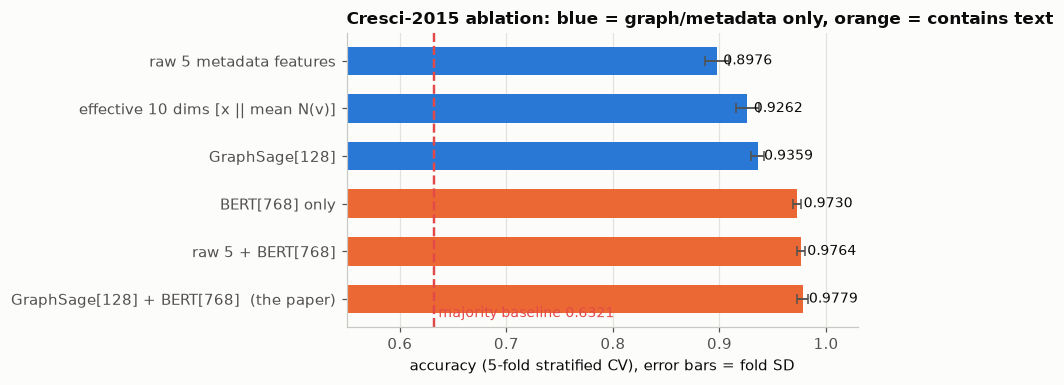

In [3]:
# --- Chart: the ablation, with the floor and the noise band ----------------
fig, ax = plt.subplots(figsize=(8.0, 3.6))
d = ABLATION.iloc[::-1]
cols = [C["blue"] if "BERT" not in n else C["orange"] for n in d["feature_set"]]
ax.barh(d["feature_set"], d["accuracy"], xerr=d["accuracy_std"],
        color=cols, height=0.6, error_kw=dict(ecolor="#52514e", capsize=3, lw=1.2))
ax.axvline(MAJORITY_CRESCI, color=C["red"], lw=1.6, ls="--")
ax.text(MAJORITY_CRESCI + 0.004, -0.45, f"majority baseline {MAJORITY_CRESCI:.4f}",
        color=C["red"], fontsize=9, va="bottom")
for y, v in enumerate(d["accuracy"]):
    ax.text(v + 0.006, y, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlim(0.55, 1.03)
ax.set_xlabel("accuracy (5-fold stratified CV), error bars = fold SD")
ax.set_title("Cresci-2015 ablation: blue = graph/metadata only, orange = contains text")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Figure 1.** Everything clears the floor comfortably, so the interesting
question is not "does it work" but "what is each piece worth". Read the top three
bars: adding the **entire** 128-dimensional graph branch to BERT moves accuracy
from 0.9730 to 0.9779. The error bars are as large as the difference.

In [4]:
# --- The marginal contributions, against the fold sigma ---------------------
acc = dict(zip(ABLATION["feature_set"], ABLATION["accuracy"]))
MARGINALS = pd.DataFrame([
    ("GraphSage[128]", "BERT[768]",
     acc["GraphSage[128] + BERT[768]  (the paper)"] - acc["BERT[768] only"]),
    ("GraphSage[128]", "raw 5 + BERT[768]",
     acc["GraphSage[128] + BERT[768]  (the paper)"] - acc["raw 5 + BERT[768]"]),
    ("BERT[768]", "GraphSage[128]",
     acc["GraphSage[128] + BERT[768]  (the paper)"] - acc["GraphSage[128]"]),
    ("raw 5 metadata", "BERT[768]",
     acc["raw 5 + BERT[768]"] - acc["BERT[768] only"]),
], columns=["adding", "to", "gain"])
MARGINALS["in_units_of_fold_sigma"] = MARGINALS["gain"] / FOLD_SIGMA
MARGINALS["verdict"] = np.where(MARGINALS["gain"].abs() > FOLD_SIGMA,
                                "outside noise", "INSIDE NOISE")
print(f"fold sigma = {FOLD_SIGMA:.4f}\n")
print(MARGINALS.round(4).to_string(index=False))

fold sigma = 0.0063

        adding                to   gain  in_units_of_fold_sigma       verdict
GraphSage[128]         BERT[768] 0.0049                  0.7726  INSIDE NOISE
GraphSage[128] raw 5 + BERT[768] 0.0015                  0.2378  INSIDE NOISE
     BERT[768]    GraphSage[128] 0.0421                  6.6258 outside noise
raw 5 metadata         BERT[768] 0.0034                  0.5348  INSIDE NOISE


So the *graph* half is the one that adds nothing to the text half. Stated the
other way round, the text half adds 3.7 points to the graph half — the two are
**not symmetric**.

But they are still substitutes, and the result that makes them so is this one.

In [5]:
# --- Verified constants: the classifier head -------------------------------
# Source: 01-info-propagation/bot-detection-paper/results/results_trained.csv
# EVIDENCE-INDEX.md sect. 2, third table.
TRAINED = pd.DataFrame([
    ("untrained SAGEConv[128] + linear SVM  (the paper)", 0.9358622161364323, 0.006348975042113),
    ("untrained SAGEConv[128] + MLP head  -- NO TEXT",    0.9774884854089235, 0.005091014707280),
    ("trained SAGEConv[128] + head",                      0.9739047652920291, 0.004933452890169),
], columns=["arm", "accuracy", "accuracy_std"])
print(f"majority baseline {MAJORITY_CRESCI:.4f}")
print(TRAINED.round(4).to_string(index=False))
print()
# EVIDENCE-INDEX.md sect. 2, "Derived in this folder"
print(f"MLP over linear SVM      : {0.9774884854089235 - 0.9358622161364323:+.4f}")
print(f"trained over untrained   : {0.9739047652920291 - 0.9774884854089235:+.4f}")
print(f"full 896-dim pipeline    :  {acc['GraphSage[128] + BERT[768]  (the paper)']:.4f}")
print(f"...minus the no-text arm : {acc['GraphSage[128] + BERT[768]  (the paper)'] - 0.9774884854089235:+.4f}"
      f"   (fold sigma {0.005358977469398:.4f})")

majority baseline 0.6321
                                              arm  accuracy  accuracy_std
untrained SAGEConv[128] + linear SVM  (the paper)    0.9359        0.0063
   untrained SAGEConv[128] + MLP head  -- NO TEXT    0.9775        0.0051
                     trained SAGEConv[128] + head    0.9739        0.0049

MLP over linear SVM      : +0.0416
trained over untrained   : -0.0036
full 896-dim pipeline    :  0.9779
...minus the no-text arm : +0.0004   (fold sigma 0.0054)


**0.9775 with no text whatsoever**, against 0.9779 for the full 896-dimensional
method — a difference of 0.0004 against a fold σ of 0.0054. Five metadata counts,
their neighbourhood means, and a small MLP reproduce the entire published
pipeline.

And two things that sound like architecture choices turn out to be worth nothing
and everything respectively:

- **training the graph layer: −0.0036.** Nothing, and slightly negative.
- **replacing the linear SVM with an MLP: +0.0416.** Roughly ten times what any
  architectural choice in the paper is worth.

The binding constraint is the **linear kernel**, not the untrained layer. Which
brings us to why the untrained layer matters so little.

---

## 2. F2 — building the "128-dimensional embedding" yourself

This is the part to do slowly, because it is the most convincing argument in the
series and it takes fifteen lines.

With PyTorch Geometric's defaults, one untrained `SAGEConv(5, 128)` layer
computes, for each node $v$:

$$h_v \;=\; W_\ell \cdot \operatorname*{mean}_{u \in N(v)} x_u \;+\; b \;+\; W_r \cdot x_v$$

where $W_\ell, W_r \in \mathbb{R}^{128 \times 5}$ and $b \in \mathbb{R}^{128}$ are
**random and never updated** — the source paper states (Sect. 3.5) that "training
epochs and optimization tasks are not required due to the lack of a prediction
head".

Look at what goes in. The layer sees the node's own 5 features and the 5-vector
mean of its neighbours' features: **10 numbers**. Everything after that is a
fixed linear map. So

$$h_v = \underbrace{[\,W_r \;\; W_\ell\,]}_{128 \times 10} \begin{bmatrix} x_v \\ \overline{x}_{N(v)} \end{bmatrix} + b$$

is an **affine map of a 10-vector**, and the 128 columns of the output matrix can
have rank at most 10 (11 counting the bias direction).

Let us build it and look.

In [6]:
# --- An untrained SAGEConv(5, 128), from scratch, in numpy -----------------
rng = np.random.default_rng(SEED)

N_NODES, F_IN, F_OUT = 400, 5, 128

# A random graph. Structure is irrelevant to the argument -- any graph works.
A = (rng.random((N_NODES, N_NODES)) < 0.03).astype(float)
np.fill_diagonal(A, 0.0)
deg = A.sum(1, keepdims=True)

X = rng.normal(size=(N_NODES, F_IN))              # node features
NBR = np.divide(A @ X, np.maximum(deg, 1.0))      # mean of the neighbours' features

# Glorot-style random init, never trained -- exactly the paper's setting.
s = np.sqrt(1.0 / F_IN)
W_l = rng.uniform(-s, s, size=(F_OUT, F_IN))      # applied to the neighbour mean
W_r = rng.uniform(-s, s, size=(F_OUT, F_IN))      # applied to the node itself
b   = rng.uniform(-s, s, size=F_OUT)

H = NBR @ W_l.T + X @ W_r.T + b                   # (400, 128) -- "the embedding"

# The 10 numbers the layer actually saw:
X10 = np.hstack([X, NBR])                         # (400, 10)

print(f"embedding H : {H.shape}   -- '128 network feature dimensions'")
print(f"its inputs  : {X10.shape}   -- [x_v || mean N(v)]")

embedding H : (400, 128)   -- '128 network feature dimensions'
its inputs  : (400, 10)   -- [x_v || mean N(v)]


In [7]:
# --- The singular spectrum of the 128 columns ------------------------------
# Centre first: the bias b is a constant offset, i.e. one extra rank direction
# that is the same for every node and carries no per-node information.
sv = np.linalg.svd(H - H.mean(0), compute_uv=False)

print("singular values 1..14 of the centred 128-column embedding:")
for i, v in enumerate(sv[:14], start=1):
    print(f"  sigma_{i:<3d} {v:12.6e}")
print(f"\nsigma_10 / sigma_11 = {sv[9] / sv[10]:.3e}")
print(f"numerical rank      = {np.linalg.matrix_rank(H - H.mean(0))}")

singular values 1..14 of the centred 128-column embedding:
  sigma_1   6.823711e+01
  sigma_2   6.255393e+01
  sigma_3   5.881502e+01
  sigma_4   5.575377e+01
  sigma_5   5.028199e+01
  sigma_6   1.965251e+01
  sigma_7   1.824571e+01
  sigma_8   1.700751e+01
  sigma_9   1.557408e+01
  sigma_10  1.383956e+01
  sigma_11  2.807906e-14
  sigma_12  6.867697e-15
  sigma_13  6.084451e-15
  sigma_14  5.978055e-15

sigma_10 / sigma_11 = 4.929e+14
numerical rank      = 10


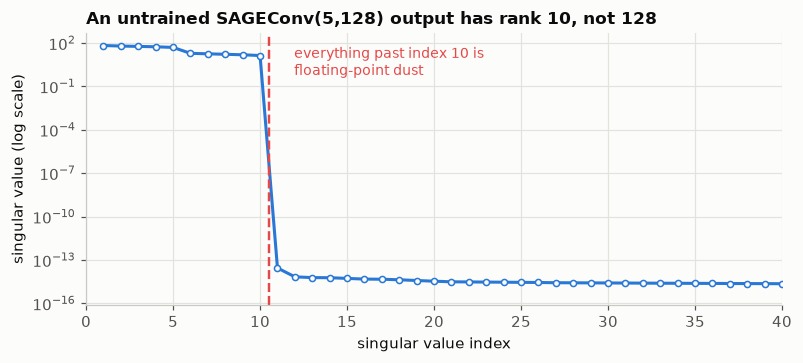

In [8]:
# --- Chart: the cliff ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.4, 3.4))
k = np.arange(1, len(sv) + 1)
ax.semilogy(k, np.maximum(sv, 1e-18), "o-", color=C["blue"], ms=4, mfc="#fcfcfb")
ax.axvline(10.5, color=C["red"], lw=1.6, ls="--")
ax.text(11.5, sv[0], "  everything past index 10 is\n  floating-point dust",
        color=C["red"], fontsize=9, va="top")
ax.set_xlabel("singular value index")
ax.set_ylabel("singular value (log scale)")
ax.set_title("An untrained SAGEConv(5,128) output has rank 10, not 128")
ax.set_xlim(0, 40)
plt.tight_layout(); plt.show()

**Figure 2.** The drop between index 10 and index 11 is many orders of magnitude
— it is the gap between real signal and double-precision rounding error. **118 of
the 128 "network feature" dimensions are exact linear combinations of the other
10.** Nothing about this depends on the graph, the features or the seed; it
follows from the layer's closed form.

### The measured version, on the real corpus

The replication asserts this as a property rather than trusting the argument.
From `checks.json`:

| claim | measured |
|---|---|
| the layer matches PyG's closed form | error **< 1e-05** |
| the layer is exactly affine in the 10 numbers | reconstructed to **< 1e-05** |
| its 128 columns have rank ≤ 10 | rank **10**, σ₁₀/σ₁₁ = **6.8 × 10⁶** |
| a linear SVM gains nothing from the projection | 128-dim **0.880** vs 10 raw dims **0.880** |

*(Source: `01-info-propagation/bot-detection-paper/results/checks.json`,
EVIDENCE-INDEX.md §3.)*

In [9]:
# --- And the consequence: a linear model cannot tell the two apart ---------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# A label that genuinely depends on the graph, so the task is not trivial.
w = rng.normal(size=10)
logit = X10 @ w + 0.35 * rng.normal(size=N_NODES)
y = (logit > np.median(logit)).astype(int)

def cv_acc(F, y, Cpen):
    """5-fold CV accuracy of an L2 logistic regression. C is the INVERSE penalty."""
    pipe = make_pipeline(StandardScaler(),
                         LogisticRegression(C=Cpen, max_iter=5000))
    return cross_val_score(pipe, F, y, cv=5, scoring="accuracy").mean()

print(f"majority baseline            {max(y.mean(), 1 - y.mean()):.4f}")
print()
print("Weak penalty (C = 100), where regularisation geometry cannot matter:")
print(f"  10 input dims   [x || mean N(v)]  {cv_acc(X10, y, 100.0):.4f}")
print(f"  128-dim 'GraphSage embedding'     {cv_acc(H,   y, 100.0):.4f}")

majority baseline            0.5000

Weak penalty (C = 100), where regularisation geometry cannot matter:
  10 input dims   [x || mean N(v)]  0.9725
  128-dim 'GraphSage embedding'     0.9725


Identical, as they must be: a linear model on $H = MX_{10}^\top + b$ and a linear
model on $X_{10}$ span the same set of decision functions when $M$ has full row
rank in the 10-dimensional input space. The random projection to 128 dimensions
cannot create information.

**This is not a criticism of GraphSAGE.** It is a description of what *one
untrained layer* does. Notebook 00's definition told you the layer sees exactly
$x_v$ and $\overline{x}_{N(v)}$; F2 is just that observation taken seriously.

---

## 3. "But the 128 dimensions *do* score higher" — the objection, answered

Here is the fact that looks like a refutation, and it is the subtlest point in
the findings.

At scikit-learn's default `C = 1`, the 128-dimensional embedding scores
**+0.0096** over the 10 numbers it is computed from (0.9262 → 0.9359,
`results_regularization.csv`). If the two carry identical information, how?

**Because L2 regularisation is not invariant under a change of basis.** The
penalty $\lVert w \rVert_2^2$ is defined in the coordinates you happen to be
using. A random projection spreads 10 informative directions across 128
coordinates; per-coordinate standardisation then rescales them; and the SVM's
penalty consequently falls differently on the same underlying function. That is
**preconditioning**, not information.

This makes a prediction that can be checked, and that could have failed:
**weaken the penalty and the gap must vanish.** Let us test it on synthetic data
before looking at the measured version.

One honest caveat, stated before the demo rather than after it: **the *sign* of
the gap depends on the geometry of the particular basis** — on whether the
projection spreads the useful directions out or concentrates them. What the
argument forces is not the sign but the **magnitude**: whatever the gap is at a
strong penalty, it must decay to zero as the penalty weakens, because at that
limit both models can express the same set of functions. In the synthetic
construction below the gap happens to be negative; on Cresci-2015 it is positive.
Both decay.

In [10]:
# --- Live: a low-rank problem, randomly projected, penalty swept -----------
# 10 informative dimensions with wildly heterogeneous scales (as raw counts have),
# randomly projected to 128. The projected version contains EXACTLY the same
# information -- it is an invertible-on-its-range linear map of the 10.
# Averaged over 16 draws, because a single 5-fold CV estimate is far too noisy
# to read a 0.001 effect off (which is itself one of this series' lessons).
def reg_trial(seed, n=600, r=10, D=128, noise=1.6):
    g = np.random.default_rng(seed)
    Z = g.normal(size=(n, r)) * np.logspace(0, 2, r)   # scales spanning 100x
    P = g.normal(size=(r, D)) / np.sqrt(r)
    Zbig = Z @ P                                       # same information, new basis
    beta = np.zeros(r); beta[0] = 1.0
    lin = (Z / Z.std(0)) @ beta
    yz = ((lin + noise * g.normal(size=n)) > 0).astype(int)
    return [(cv_acc(Z, yz, Cp), cv_acc(Zbig, yz, Cp)) for Cp in C_GRID]

C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
R = np.array([reg_trial(s) for s in range(16)]).mean(axis=0)
SYNTH_REG = pd.DataFrame({"C": C_GRID, "acc_10dim": R[:, 0], "acc_projected_128": R[:, 1]})
SYNTH_REG["delta"] = SYNTH_REG["acc_projected_128"] - SYNTH_REG["acc_10dim"]
SYNTH_REG["abs_delta"] = SYNTH_REG["delta"].abs()

print("Both feature sets contain EXACTLY the same information, by construction.")
print("Mean over 16 independent draws, 5-fold CV each.\n")
print(SYNTH_REG.round(4).to_string(index=False))

Both feature sets contain EXACTLY the same information, by construction.
Mean over 16 independent draws, 5-fold CV each.

     C  acc_10dim  acc_projected_128   delta  abs_delta
  0.01     0.6684             0.5248 -0.1436     0.1436
  0.03     0.6679             0.5468 -0.1211     0.1211
  0.10     0.6668             0.5957 -0.0710     0.0710
  0.30     0.6670             0.6361 -0.0308     0.0308
  1.00     0.6670             0.6594 -0.0076     0.0076
  3.00     0.6670             0.6638 -0.0032     0.0032
 10.00     0.6671             0.6660 -0.0010     0.0010
100.00     0.6671             0.6674  0.0003     0.0003


The gap is large where the penalty binds — a full **0.14** here, which is enormous
— and collapses monotonically to 0.0003 where it does not, on data where we
*know* the two representations are informationally identical because we built
them that way. A difference of 0.14 accuracy between two provably equivalent
feature sets is worth pausing on: representation geometry can dominate anything
a paper is likely to be measuring.

Now the measured version, on the real corpus.

In [11]:
# --- Verified constants: the regularisation control ------------------------
# Source: 01-info-propagation/bot-detection-paper/results/results_regularization.csv
# EVIDENCE-INDEX.md sect. 3.
REG = pd.DataFrame([
    (0.001, 0.8249403375242295, 0.8581407714331443),
    (0.01,  0.8737988369818435, 0.8885124393149930),
    (0.1,   0.9054910817491508, 0.9194508562587804),
    (1.0,   0.9262425977628794, 0.9358622161364323),
    (10.0,  0.9407666316931339, 0.9432189283872459),
    (100.0, 0.9441616132875714, 0.9445391496096598),
], columns=["C", "acc_10dim", "acc_sage128"])
REG["delta"] = REG["acc_sage128"] - REG["acc_10dim"]
print(f"Cresci-2015, 5-fold CV, majority baseline {MAJORITY_CRESCI:.4f}")
print(REG.round(4).to_string(index=False))

Cresci-2015, 5-fold CV, majority baseline 0.6321
      C  acc_10dim  acc_sage128  delta
  0.001     0.8249       0.8581 0.0332
  0.010     0.8738       0.8885 0.0147
  0.100     0.9055       0.9195 0.0140
  1.000     0.9262       0.9359 0.0096
 10.000     0.9408       0.9432 0.0025
100.000     0.9442       0.9445 0.0004


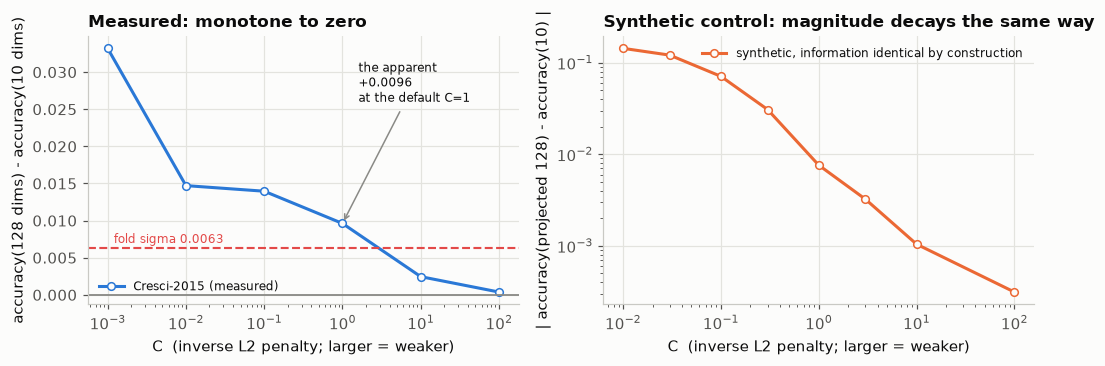

In [12]:
# --- Chart: measured and synthetic, the same shape -------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=False)

ax = axes[0]
ax.semilogx(REG["C"], REG["delta"], "o-", color=C["blue"], ms=5, mfc="#fcfcfb",
            label="Cresci-2015 (measured)")
ax.axhline(0, color=C["grey"], lw=1.2)
ax.axhline(FOLD_SIGMA, color=C["red"], lw=1.4, ls="--")
ax.text(0.0012, FOLD_SIGMA * 1.1, f"fold sigma {FOLD_SIGMA:.4f}", color=C["red"], fontsize=8)
ax.annotate(f"the apparent\n+{REG.loc[REG.C == 1.0, 'delta'].iloc[0]:.4f}\nat the default C=1",
            xy=(1.0, REG.loc[REG.C == 1.0, "delta"].iloc[0]), xytext=(1.6, 0.026),
            fontsize=8, color=C["ink"],
            arrowprops=dict(arrowstyle="->", color=C["grey"], lw=1))
ax.set_xlabel("C  (inverse L2 penalty; larger = weaker)")
ax.set_ylabel("accuracy(128 dims) - accuracy(10 dims)")
ax.set_title("Measured: monotone to zero")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
ax.loglog(SYNTH_REG["C"], SYNTH_REG["abs_delta"], "o-", color=C["orange"], ms=5,
          mfc="#fcfcfb", label="synthetic, information identical by construction")
ax.set_xlabel("C  (inverse L2 penalty; larger = weaker)")
ax.set_ylabel("| accuracy(projected 128) - accuracy(10) |")
ax.set_title("Synthetic control: magnitude decays the same way")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

**Figure 3.** Left: the measured gap on Cresci-2015 decays monotonically from
+0.0332 at C = 0.001 to **+0.0004** at C = 100. Right: the same decay in
magnitude on synthetic data where the two feature sets provably carry the same
information (note the log scale, and note that its sign is negative — see the
caveat above). The conclusion the reader should draw is that the +0.0096 at C = 1
is regularisation geometry, and that any claim about the two representations
being equivalent must be made **at large C**; at the default they differ by about
a point for basis reasons alone.

### A second, independent confirmation

Since the layer is untrained, **its random seed is the model**. If the 128
dimensions carried information beyond the 10, a different random basis would
express something different. Varying only that seed across 10 seeds
(`results_seeds.csv`, EVIDENCE-INDEX.md §3):

In [13]:
# --- Verified constants: seed sensitivity of the untrained layer -----------
# Source: results_seeds.csv, sage_seed 0..9. EVIDENCE-INDEX.md sect. 3 gives
# min 0.9358622161364323 (seed 0), max 0.9377488307577402 (seed 6),
# spread 0.0018866146213079. Per-seed values from 02-THE-TEXT-BRANCH.md sect. 4.
SEED_ACC = np.array([0.9359, 0.9377, 0.9370, 0.9364, 0.9366,
                     0.9368, 0.9377, 0.9370, 0.9368, 0.9369])
SEED_SPREAD = 0.0018866146213079   # full-precision, EVIDENCE-INDEX.md sect. 3

print(f"accuracy across 10 random initialisations of the untrained layer:")
print("  " + "  ".join(f"{v:.4f}" for v in SEED_ACC))
print(f"\nspread     {SEED_SPREAD:.4f}")
print(f"fold sigma {FOLD_SIGMA:.4f}")
print(f"ratio      {SEED_SPREAD / FOLD_SIGMA:.2f}x the fold noise")

accuracy across 10 random initialisations of the untrained layer:
  0.9359  0.9377  0.9370  0.9364  0.9366  0.9368  0.9377  0.9370  0.9368  0.9369

spread     0.0019
fold sigma 0.0063
ratio      0.30x the fold noise


A random change of basis cannot alter what a linear model can express, and the
measurement agrees: 0.0019 of spread against 0.0063 of fold noise.

---

## 4. Why the text branch is weaker than it looks too

The text side deserves the same scrutiny. The paper's recipe (its Listing A.1) is:
mean over token vectors of the last hidden state per tweet, then mean over the
user's tweets. That is a lot of averaging — a user's 768-vector ends up close to
the corpus mean, and the *between-user* variance a classifier needs is small.

The cost is visible in the model comparison (`results_replicate.csv`,
EVIDENCE-INDEX.md §2):

| variant | dim | accuracy | ±SD | wall time |
|---|---|---|---|---|
| GraphSage + SVM | 128 | 0.9359 | 0.0063 | 0.4 s |
| GraphSage + **BERT** | 896 | 0.9789 | 0.0020 | 17.3 s |
| GraphSage + **DistilBERT** | 896 | 0.9779 | 0.0054 | 19.5 s |

BERT over DistilBERT is worth **+0.0009** against a fold σ of 0.0054. The choice
of language model does not matter on this benchmark either.

---

## 5. The consequence — there is no headroom

This is what F1 and F2 are *for*. Put the numbers on one axis.

In [14]:
# --- The headroom calculation ----------------------------------------------
floor_raw5   = ABLATION.loc[ABLATION.feature_set == "raw 5 metadata features", "accuracy"].iloc[0]
ceiling      = acc["GraphSage[128] + BERT[768]  (the paper)"]
no_text      = 0.9774884854089235      # untrained SAGE + MLP, no text at all
linear_gain  = 0.9774884854089235 - 0.9358622161364323

print(f"majority baseline                          {MAJORITY_CRESCI:.4f}")
print(f"raw 5 metadata features                    {floor_raw5:.4f}")
print(f"five metadata numbers + an MLP, no text    {no_text:.4f}")
print(f"the full 896-dimensional published method  {ceiling:.4f}")
print()
print(f"total range, metadata floor to ceiling     {ceiling - floor_raw5:.4f}  ({100*(ceiling-floor_raw5):.1f} points)")
print(f"...of which bought by dropping linearity   {linear_gain:.4f}  ({100*linear_gain:.1f} points)")
print(f"headroom left above the no-text arm        {ceiling - no_text:.4f}")
print(f"fold noise on that comparison              {0.005358977469398:.4f}")
print()
print("A new feature evaluated here has roughly 0.0004-0.002 of room")
print("against 0.005-0.006 of noise.  It will appear to work, or not to work, at random.")

majority baseline                          0.6321
raw 5 metadata features                    0.8976
five metadata numbers + an MLP, no text    0.9775
the full 896-dimensional published method  0.9779

total range, metadata floor to ceiling     0.0804  (8.0 points)
...of which bought by dropping linearity   0.0416  (4.2 points)
headroom left above the no-text arm        0.0004
fold noise on that comparison              0.0054

A new feature evaluated here has roughly 0.0004-0.002 of room
against 0.005-0.006 of noise.  It will appear to work, or not to work, at random.


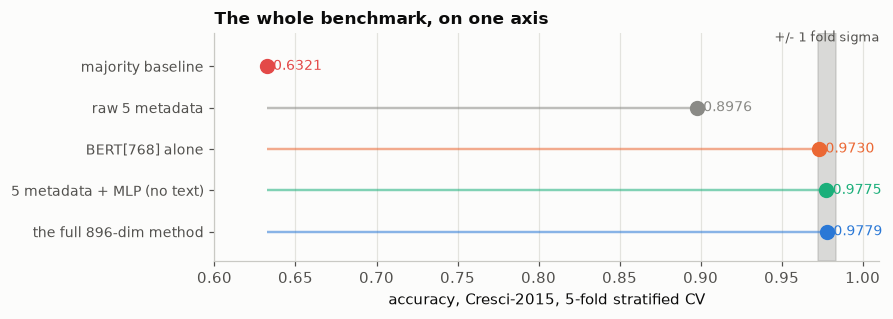

In [15]:
# --- Chart: the ladder, with the noise band drawn to scale -----------------
# One row per arm, so nothing collides; the grey band is one fold SD around
# the published method, drawn to the same scale as the accuracies themselves.
marks = [("the full 896-dim method",     ceiling,            C["blue"]),
         ("5 metadata + MLP (no text)",  no_text,            C["aqua"]),
         ("BERT[768] alone",             0.9730236693756336, C["orange"]),
         ("raw 5 metadata",              floor_raw5,         C["grey"]),
         ("majority baseline",           MAJORITY_CRESCI,    C["red"])]
SIG = 0.005358977469398   # fold SD of the 896-dim arm, results_ablation.csv

fig, ax = plt.subplots(figsize=(8.2, 3.0))
ax.axvspan(ceiling - SIG, ceiling + SIG, color=C["grey"], alpha=0.30, zorder=1)
for i, (name, v, col) in enumerate(marks):
    ax.hlines(i, MAJORITY_CRESCI, v, color=col, lw=1.6, alpha=0.55, zorder=2)
    ax.plot([v], [i], "o", color=col, ms=9, zorder=3)
    ax.text(v + 0.004, i, f"{v:.4f}", va="center", fontsize=9, color=col)
ax.set_yticks(range(len(marks)))
ax.set_yticklabels([m[0] for m in marks], fontsize=9)
ax.text(ceiling, len(marks) - 0.4, "+/- 1 fold sigma", ha="center",
        fontsize=8.5, color="#52514e")
ax.set_xlim(0.60, 1.01); ax.set_ylim(-0.7, len(marks) - 0.2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("accuracy, Cresci-2015, 5-fold stratified CV")
ax.set_title("The whole benchmark, on one axis")
plt.tight_layout(); plt.show()

**Figure 4.** The grey band is one fold standard deviation around the published
method. The "no text at all" arm sits **inside** it. The reader should conclude
that Cresci-2015 under 5-fold CV cannot distinguish the published architecture
from five metadata numbers with a small non-linear head — and therefore cannot
adjudicate any new feature either. That is why the follow-on project
(notebook 04) makes **cross-dataset transfer** its primary claim rather than
within-corpus accuracy.

## What this licenses

- On Cresci-2015 under 5-fold CV, the graph branch adds **+0.0049** to the text branch and **+0.0015** to raw-metadata-plus-text. Both are inside fold noise (σ ≈ 0.0063).
- The 128-dimensional embedding contains exactly the information in 10 numbers. This is **provable from the layer's closed form**, and was independently measured: rank 10, σ₁₀/σ₁₁ = 6.8 × 10⁶.
- The +0.0096 the 128-dim representation shows at C = 1 is regularisation geometry: it decays monotonically to +0.0004 at C = 100, and the same decay reproduces on synthetic data of provably identical information.
- Training the graph layer is worth **−0.0036**; replacing the linear kernel with an MLP is worth **+0.0416**.
- The benchmark is saturated: five metadata numbers with an MLP reach 0.9775 against the full method's 0.9779, inside a fold σ of 0.0054.

## What this does NOT license

- *"Text embeddings are useless for bot detection."* BERT alone (0.9730) beats the graph branch alone (0.9359) by 3.7 points. The finding is **redundancy on this benchmark**, not uselessness.
- *"GraphSAGE does not work."* This paper's GraphSAGE is untrained, one layer, and fed a graph in which 63.8% of labelled users have no featured neighbours (notebook 03). None of those is a property of GraphSAGE.
- *"Random projections never help."* They demonstrably change what a *regularised* linear model finds. The claim is only that they add no information, which is why the effect vanishes as the penalty weakens.
- Any claim about a different corpus or a different protocol. Everything here is Cresci-2015 under 5-fold stratified CV.

---

**Next:** [02 — the α question](02-the-alpha-question.ipynb), which asks what the
Rényi order α actually does to a distribution, and then why it did not move the
result on the task it was introduced for.